# Hierarchical multi-tier pattern

In complex organizations and systems, a single-tier hierarchy (one manager with direct reports) often is not sufficient. Real-world organizations typically have multiple management layers where middle managers coordinate their own teams. This multi-tier hierarchical pattern mirrors such structures. For example, software development teams need more sophisticated coordination mechanisms. Teams need bidirectional communication for reporting issues, parallel execution for efficiency, error handling for quality assurance, and cross-team coordination to ensure components integrate properly.
- **Bidirectional communication:** Workers can report issues back to team leads, who can escalate to the project manager.
- **Parallel execution:** Multiple workers operate simultaneously for faster completion.
- **Error handling and quality checks:** Team leads validate worker outputs before integration.
- **Cross-team coordination:** Project manager shares context (like API contracts) between frontend and backend teams.

This pattern is particularly valuable for:
- Complex projects requiring multiple specialized teams.
- Systems where component integration and quality are critical.
- Projects where issues need escalation paths for resolution.
- Organizations requiring clear accountability and coordination.

In this notebook, we will implement a 3-tier software development system:

**Tier 3 - Worker Agents (4 specialists):** Each runs a ReAct loop (Reason → Act → Observe → repeat) with access to technical tools:
- Backend Developer (API, business logic).
- Database Expert (schema, queries).
- UI Developer (components, styling).
- UX Designer (user flows, wireframes).

**Tier 2 - Team Lead Agents (2 managers):** Each reasons about task delegation, reviews worker outputs, and decides whether the result is acceptable:
- Backend Team Lead (coordinates backend + database).
- Frontend Team Lead (coordinates UI + UX).

**Tier 1 - Project Manager:** Reasons about the overall project, shares context between teams, and evaluates final integration:
- Coordinates both teams, manages quality, handles escalations.

This demonstrates how improved hierarchical patterns handle real-world complexity with communication, error handling and cross-team coordination.

In [1]:
import os
import json
from typing import TypedDict, Sequence, Annotated, List, Dict, Literal
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, START, END
from langchain_core.messages import BaseMessage, SystemMessage, HumanMessage, AIMessage, ToolMessage
from langchain_core.tools import tool
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode
from langchain_core.runnables.graph import MermaidDrawMethod
from IPython.display import HTML, display
import base64

### Initialize the language model

We use a consistent model across all tiers of the hierarchy for reliable coordination and communication.

In [2]:
# Initialize the OpenAI language model
# Using temperature=0 for consistent, reliable project execution
llm = ChatOpenAI(model="gpt-4o-mini-2024-07-18", api_key=os.getenv("OPENAI_API_KEY", "").strip(), temperature=0)

### Define tools for worker agents
Autonomous agents must have tools they can invoke based on their own reasoning. These tools represent the actions available to worker agents - the means by which they interact with the world beyond the LLM itself. Workers will autonomously decide when and which tools to call during their reasoning loops.

In [3]:
@tool
def search_best_practices(topic: str) -> str:
    """Look up engineering best practices for a given topic."""
    practices = {
        "authentication": "Use bcrypt for password hashing (min cost 12). Implement JWT with short expiry (15 min access, 7 day refresh). Store refresh tokens server-side. Rate limit login to 5 attempts per minute. Use HTTPS only. Implement MFA for sensitive operations.",
        "password reset": "Generate cryptographically secure tokens using os.urandom(32). Set token expiry to 1 hour. Invalidate token after single use. Send reset link to verified email. Log all reset attempts. Do not reveal if email exists.",
        "database schema": "Use UUIDs as primary keys, not sequential integers. Add created_at and updated_at timestamps to every table. Index foreign keys and columns used in WHERE clauses. Use NOT NULL constraints by default. Never store plaintext secrets.",
        "api design": "Use RESTful conventions: nouns not verbs, plural resources. Version your API (/v1/). Return proper HTTP status codes (201 for create, 204 for delete). Use pagination for list endpoints. Document with OpenAPI/Swagger.",
        "frontend forms": "Validate both client-side (UX) and server-side (security). Show inline errors near the relevant field. Disable submit button while processing. Clear sensitive fields after submission. Use autocomplete attributes for accessibility.",
        "ux flows": "Minimize steps to complete authentication. Show password strength indicator. Provide clear error messages without exposing system details. Support keyboard navigation. Confirm destructive actions. Redirect to original destination after login.",
    }
    for key, value in practices.items():
        if key in topic.lower():
            return value
    return f"Best practice guidance for '{topic}': Apply the principle of least privilege, fail securely, and keep implementations simple and auditable."

@tool
def validate_design(design_type: str, content: str) -> str:
    """Validate a design artifact and return feedback on missing elements or issues."""
    checklists = {
        "api": ["endpoints defined", "request/response format", "authentication method", "error responses", "HTTP methods"],
        "schema": ["primary keys", "foreign keys", "indexes", "constraints", "timestamps"],
        "ui component": ["input validation", "error states", "loading states", "accessibility", "responsive layout"],
        "ux flow": ["entry points", "success path", "error path", "edge cases", "exit points"],
    }
    feedback = []
    for design_key, checklist in checklists.items():
        if design_key in design_type.lower():
            missing = [item for item in checklist if item not in content.lower()]
            if missing:
                feedback.append(f"Missing elements: {', '.join(missing)}")
            else:
                feedback.append("All required elements present.")
            return f"Validation result for {design_type}: {' '.join(feedback)}"
    return f"Validation complete for {design_type}: design appears structurally sound."

@tool
def get_api_contract(service: str) -> str:
    """Retrieve the agreed API contract for a given service, as defined by the backend team."""
    contracts = {
        "authentication": json.dumps({
            "POST /v1/auth/register": {"body": {"email": "string", "password": "string", "name": "string"}, "response": {"user_id": "uuid", "email": "string"}},
            "POST /v1/auth/login": {"body": {"email": "string", "password": "string"}, "response": {"access_token": "string", "refresh_token": "string", "expires_in": 900}},
            "POST /v1/auth/logout": {"headers": {"Authorization": "Bearer <token>"}, "response": {"message": "string"}},
            "POST /v1/auth/password-reset/request": {"body": {"email": "string"}, "response": {"message": "string"}},
            "POST /v1/auth/password-reset/confirm": {"body": {"token": "string", "new_password": "string"}, "response": {"message": "string"}},
        }, indent=2),
    }
    for key, contract in contracts.items():
        if key in service.lower():
            return contract
    return f"No contract found for '{service}'. Coordinate with the backend team."


# Collect tools for each team
backend_tools = [search_best_practices, validate_design]
frontend_tools = [search_best_practices, validate_design, get_api_contract]

# Bind tools to model variants for each team
llm_with_backend_tools = llm.bind_tools(backend_tools)
llm_with_frontend_tools = llm.bind_tools(frontend_tools)

print("✓ Worker tools defined")

✓ Worker tools defined


## Part 1: Build worker agents (Tier 3 - Specialist workers)
Worker agents are the autonomous specialists who perform the actual implementation work. The agent reasons about what to do, takes an action (tool call or produces output), observes the result, then reasons again. This loop continues until the agent decides its work is done. Here, each worker:
- Decides autonomously which tools to consult.
- Observes tool results and incorporates them into its reasoning.
- Iterates until it is satisfied with its output.

### Autonomous reasoning loop structure
Every worker graph follows the same loop structure:
```
START → reason → [tool call?] → act → reason → [done?] → END
                     ↑_________________________|
```
The `reason` node calls the LLM. If the response contains tool calls, the agent routes to `act` to execute them, then loops back to `reason` with the observations. When the LLM produces a final response with no tool calls, the agent exits.

### Backend team workers

In [4]:
# Shared state structure for all worker agents
class WorkerAgentState(TypedDict):
    """State for autonomous worker agents."""
    messages: Annotated[Sequence[BaseMessage], add_messages]
    task: str       # The task assigned by the team lead
    output: str     # The final deliverable produced by this agent
    tool_calls_count: int

def should_continue_or_end(state: WorkerAgentState) -> Literal["act", "end"]:
    """Routing function: continue acting if there are tool calls, otherwise end."""
    last_message = state["messages"][-1]
    tool_calls_count = state.get("tool_calls_count", 0)

    # Stop after 5 tool calls to prevent infinite loops
    if tool_calls_count >= 5:
        return "end"
    
    if hasattr(last_message, "tool_calls") and last_message.tool_calls:
        return "act"
    return "end"

def extract_output(state: WorkerAgentState) -> WorkerAgentState:
    """Extract the final output from the agent's last message."""
    last_message = state["messages"][-1]
    return {"output": last_message.content}

# --- Backend Developer Agent ---

def backend_developer_reason(state: WorkerAgentState) -> WorkerAgentState:
    """Backend Developer reasons about server-side implementation."""
    system_prompt = SystemMessage(
        content="""You are an autonomous Backend Developer agent.

        Your responsibility: Design the server-side implementation for the task assigned to you.
        You have access to tools to look up best practices and validate your designs.
        Use them when you need guidance or want to verify your approach.

        Work through the task step by step. When your implementation is complete and
        you are confident in its quality, produce your final deliverable.
        """
    )
    response = llm_with_backend_tools.invoke([system_prompt] + list(state["messages"]))
    return {"messages": [response]}

backend_developer_graph = StateGraph(WorkerAgentState)
backend_developer_graph.add_node("reason", backend_developer_reason)
backend_developer_graph.add_node("act", ToolNode(backend_tools))
backend_developer_graph.add_node("extract", extract_output)
backend_developer_graph.add_edge(START, "reason")
backend_developer_graph.add_conditional_edges("reason", should_continue_or_end, {"act": "act", "end": "extract"})
backend_developer_graph.add_edge("act", "reason")
backend_developer_graph.add_edge("extract", END)
backend_developer_agent = backend_developer_graph.compile()

# --- Database Expert Agent ---

def database_expert_reason(state: WorkerAgentState) -> WorkerAgentState:
    """Database Expert reasons about data modeling and schema design."""
    system_prompt = SystemMessage(
        content="""You are an autonomous Database Expert agent.

        Your responsibility: Design the database schema and data access layer for the task assigned to you.
        You have access to tools to look up best practices and validate your schema designs.
        Use them to ensure your schema is production-quality.

        Work through the task step by step. When your schema is complete and validated,
        produce your final deliverable.
        """
    )
    response = llm_with_backend_tools.invoke([system_prompt] + list(state["messages"]))
    return {"messages": [response]}

database_expert_graph = StateGraph(WorkerAgentState)
database_expert_graph.add_node("reason", database_expert_reason)
database_expert_graph.add_node("act", ToolNode(backend_tools))
database_expert_graph.add_node("extract", extract_output)
database_expert_graph.add_edge(START, "reason")
database_expert_graph.add_conditional_edges("reason", should_continue_or_end, {"act": "act", "end": "extract"})
database_expert_graph.add_edge("act", "reason")
database_expert_graph.add_edge("extract", END)
database_expert_agent = database_expert_graph.compile()

print("✓ Backend worker agents created (each with autonomous ReAct loop)")

✓ Backend worker agents created (each with autonomous ReAct loop)


### Frontend team workers
Frontend workers have access to an additional tool: `get_api_contract`. This means they can autonomously retrieve the backend API specification during their reasoning loop rather than waiting for it to be handed to them. The agent decides when it needs this information and calls the tool on its own.

In [5]:
# --- UI Developer Agent ---

def ui_developer_reason(state: WorkerAgentState) -> WorkerAgentState:
    """UI Developer reasons about component design and implementation."""
    system_prompt = SystemMessage(
        content="""You are an autonomous UI Developer agent.

        Your responsibility: Design and specify the UI components for the task assigned to you.
        You have access to tools to look up best practices, validate your component designs,
        and retrieve the backend API contract so your components align with the actual API.

        Use the get_api_contract tool to understand what endpoints and data shapes the
        backend exposes. Use search_best_practices and validate_design to ensure quality.

        Work autonomously. When your UI specification is complete and validated,
        produce your final deliverable.
        """
    )
    response = llm_with_frontend_tools.invoke([system_prompt] + list(state["messages"]))
    return {"messages": [response]}

ui_developer_graph = StateGraph(WorkerAgentState)
ui_developer_graph.add_node("reason", ui_developer_reason)
ui_developer_graph.add_node("act", ToolNode(frontend_tools))
ui_developer_graph.add_node("extract", extract_output)
ui_developer_graph.add_edge(START, "reason")
ui_developer_graph.add_conditional_edges("reason", should_continue_or_end, {"act": "act", "end": "extract"})
ui_developer_graph.add_edge("act", "reason")
ui_developer_graph.add_edge("extract", END)
ui_developer_agent = ui_developer_graph.compile()

# --- UX Designer Agent ---

def ux_designer_reason(state: WorkerAgentState) -> WorkerAgentState:
    """UX Designer reasons about user flows and interaction design."""
    system_prompt = SystemMessage(
        content="""You are an autonomous UX Designer agent.

        Your responsibility: Design the user experience flows for the task assigned to you.
        You have access to tools to look up UX best practices, validate your flow designs,
        and retrieve the backend API contract to understand what the system can support.

        Use the get_api_contract tool to ground your UX flows in the actual system capabilities.
        Use search_best_practices to ensure your flows follow established UX patterns.

        Work autonomously. When your UX flow specification is complete,
        produce your final deliverable.
        """
    )
    response = llm_with_frontend_tools.invoke([system_prompt] + list(state["messages"]))
    return {"messages": [response]}

ux_designer_graph = StateGraph(WorkerAgentState)
ux_designer_graph.add_node("reason", ux_designer_reason)
ux_designer_graph.add_node("act", ToolNode(frontend_tools))
ux_designer_graph.add_node("extract", extract_output)
ux_designer_graph.add_edge(START, "reason")
ux_designer_graph.add_conditional_edges("reason", should_continue_or_end, {"act": "act", "end": "extract"})
ux_designer_graph.add_edge("act", "reason")
ux_designer_graph.add_edge("extract", END)
ux_designer_agent = ux_designer_graph.compile()

print("✓ Frontend worker agents created (each with autonomous ReAct loop)")

✓ Frontend worker agents created (each with autonomous ReAct loop)


## Part 2: Build team lead agents (Tier 2 - Middle managers) with supervisory reasoning
Team leads are not simple orchestrators that call workers and collect results. Each team lead is itself an autonomous agent that:
1. Reasons about the requirements to determine what tasks to assign.
2. Delegates tasks to autonomous worker agents.
3. Evaluates each worker's output - the team lead reads the result and reasons about whether it is acceptable.
4. Decides to accept the output or send it back with feedback for a revision.

This evaluation step is what distinguishes a true supervisory agent from a workflow node. The team lead applies its own judgment, not a fixed rule.

### Backend team lead

In [6]:
# Backend Team Lead State
class TeamLeadState(TypedDict):
    """State for team lead agents."""
    messages: Annotated[Sequence[BaseMessage], add_messages]
    requirements: str           # Requirements passed down from the project manager
    worker_outputs: List[str]   # Outputs collected from worker agents
    team_deliverable: str       # The integrated deliverable for this team

# --- Backend Team Lead Agent ---

def backend_lead_plan(state: TeamLeadState) -> TeamLeadState:
    """Backend team lead reasons about requirements and defines tasks for its workers."""
    system_prompt = SystemMessage(
        content="""You are the Backend Team Lead. You manage two autonomous worker agents:
        a Backend Developer and a Database Expert.

        Given project requirements, reason about what each worker should focus on.
        Define a clear, specific task for the Backend Developer (API endpoints, auth logic)
        and a clear, specific task for the Database Expert (schema, indexes, constraints).

        Format your response as:
        BACKEND_DEVELOPER_TASK: 
        DATABASE_EXPERT_TASK: 
        """
    )
    response = llm.invoke([system_prompt, HumanMessage(content=f"Requirements:\n{state['requirements']}")])
    return {"messages": [AIMessage(content=f"[Backend Lead — Planning]\n{response.content}")]}

def backend_lead_delegate(state: TeamLeadState) -> TeamLeadState:
    """Backend team lead delegates to its autonomous worker agents and collects outputs."""
    # Extract task assignments from the planning message
    plan_text = state["messages"][-1].content

    dev_task = ""
    db_task = ""
    for line in plan_text.splitlines():
        if line.startswith("BACKEND_DEVELOPER_TASK:"):
            dev_task = line.replace("BACKEND_DEVELOPER_TASK:", "").strip()
        elif line.startswith("DATABASE_EXPERT_TASK:"):
            db_task = line.replace("DATABASE_EXPERT_TASK:", "").strip()

    # Invoke the Backend Developer autonomous agent
    dev_result = backend_developer_agent.invoke({
        "messages": [HumanMessage(content=dev_task or state["requirements"])],
        "task": dev_task or state["requirements"],
        "output": ""
    })

    # Invoke the Database Expert autonomous agent
    db_result = database_expert_agent.invoke({
        "messages": [HumanMessage(content=db_task or state["requirements"])],
        "task": db_task or state["requirements"],
        "output": ""
    })

    outputs = [dev_result["output"], db_result["output"]]
    return {
        "worker_outputs": outputs,
        "messages": [AIMessage(content="[Backend Lead — Workers completed their tasks]")]
    }

def backend_lead_evaluate(state: TeamLeadState) -> TeamLeadState:
    """Backend team lead evaluates worker outputs and integrates them into a team deliverable."""
    system_prompt = SystemMessage(
        content="""You are the Backend Team Lead evaluating your workers' outputs.

        Review what the Backend Developer and Database Expert have produced.
        Assess whether the outputs are complete and compatible with each other.
        Integrate them into a single cohesive backend deliverable.

        If you identify gaps or inconsistencies, address them in your integration.
        Your integrated deliverable will be passed to the Project Manager.
        """
    )
    worker_outputs = state.get("worker_outputs", [])
    content = f"Backend Developer output:\n{worker_outputs[0] if len(worker_outputs) > 0 else 'N/A'}\n\nDatabase Expert output:\n{worker_outputs[1] if len(worker_outputs) > 1 else 'N/A'}"
    response = llm.invoke([system_prompt, HumanMessage(content=content)])
    return {
        "team_deliverable": response.content,
        "messages": [AIMessage(content=f"[Backend Lead — Team deliverable ready]")]
    }

# Build backend team lead graph
backend_lead_graph = StateGraph(TeamLeadState)
backend_lead_graph.add_node("plan", backend_lead_plan)
backend_lead_graph.add_node("delegate", backend_lead_delegate)
backend_lead_graph.add_node("evaluate", backend_lead_evaluate)
backend_lead_graph.add_edge(START, "plan")
backend_lead_graph.add_edge("plan", "delegate")
backend_lead_graph.add_edge("delegate", "evaluate")
backend_lead_graph.add_edge("evaluate", END)
backend_team_lead_agent = backend_lead_graph.compile()

print("✓ Backend Team Lead agent created")

✓ Backend Team Lead agent created


### Frontend team lead
The frontend team lead follows the same pattern but manages UI and UX workers. Importantly, it also reasons about the backend team's deliverable - passed down via requirements - so it can align frontend work with what the backend actually provides.

In [7]:
def frontend_lead_plan(state: TeamLeadState) -> TeamLeadState:
    """Frontend team lead reasons about requirements and defines tasks for its workers."""
    system_prompt = SystemMessage(
        content="""You are the Frontend Team Lead. You manage two autonomous worker agents:
        a UI Developer and a UX Designer.

        Given project requirements and any backend context, reason about what each
        worker should focus on. Define clear, specific tasks for each.

        Your workers can autonomously look up the API contract using their tools,
        so instruct them to do so as needed.

        Format your response as:
        UI_DEVELOPER_TASK: 
        UX_DESIGNER_TASK: 
        """
    )
    response = llm.invoke([system_prompt, HumanMessage(content=f"Requirements:\n{state['requirements']}")])
    return {"messages": [AIMessage(content=f"[Frontend Lead — Planning]\n{response.content}")]}

def frontend_lead_delegate(state: TeamLeadState) -> TeamLeadState:
    """Frontend team lead delegates to its autonomous worker agents and collects outputs."""
    plan_text = state["messages"][-1].content

    ui_task = ""
    ux_task = ""
    for line in plan_text.splitlines():
        if line.startswith("UI_DEVELOPER_TASK:"):
            ui_task = line.replace("UI_DEVELOPER_TASK:", "").strip()
        elif line.startswith("UX_DESIGNER_TASK:"):
            ux_task = line.replace("UX_DESIGNER_TASK:", "").strip()

    # Invoke the UI Developer autonomous agent
    ui_result = ui_developer_agent.invoke({
        "messages": [HumanMessage(content=ui_task or state["requirements"])],
        "task": ui_task or state["requirements"],
        "output": ""
    })

    # Invoke the UX Designer autonomous agent
    ux_result = ux_designer_agent.invoke({
        "messages": [HumanMessage(content=ux_task or state["requirements"])],
        "task": ux_task or state["requirements"],
        "output": ""
    })

    outputs = [ui_result["output"], ux_result["output"]]
    return {
        "worker_outputs": outputs,
        "messages": [AIMessage(content="[Frontend Lead — Workers completed their tasks]")]
    }

def frontend_lead_evaluate(state: TeamLeadState) -> TeamLeadState:
    """Frontend team lead evaluates worker outputs and integrates them."""
    system_prompt = SystemMessage(
        content="""You are the Frontend Team Lead evaluating your workers' outputs.

        Review what the UI Developer and UX Designer have produced.
        Assess whether the UI components and UX flows are consistent and complete.
        Integrate them into a single cohesive frontend deliverable.

        Verify that the UI implementation aligns with the UX flows and
        that both are grounded in the actual backend API contract.
        """
    )
    worker_outputs = state.get("worker_outputs", [])
    content = f"UI Developer output:\n{worker_outputs[0] if len(worker_outputs) > 0 else 'N/A'}\n\nUX Designer output:\n{worker_outputs[1] if len(worker_outputs) > 1 else 'N/A'}"
    response = llm.invoke([system_prompt, HumanMessage(content=content)])
    return {
        "team_deliverable": response.content,
        "messages": [AIMessage(content="[Frontend Lead — Team deliverable ready]")]
    }

# Build frontend team lead graph
frontend_lead_graph = StateGraph(TeamLeadState)
frontend_lead_graph.add_node("plan", frontend_lead_plan)
frontend_lead_graph.add_node("delegate", frontend_lead_delegate)
frontend_lead_graph.add_node("evaluate", frontend_lead_evaluate)
frontend_lead_graph.add_edge(START, "plan")
frontend_lead_graph.add_edge("plan", "delegate")
frontend_lead_graph.add_edge("delegate", "evaluate")
frontend_lead_graph.add_edge("evaluate", END)
frontend_team_lead_agent = frontend_lead_graph.compile()

print("✓ Frontend Team Lead agent created")

✓ Frontend Team Lead agent created


## Part 3: Build project manager (Tier 1 - Top coordinator)
The project manager is the top-level autonomous agent. It reasons about the user's request to produce a project plan, then delegates to team leads - passing appropriate context to each. Crucially, the project manager sequentially coordinates backend then frontend, so it can pass the backend deliverable as context to the frontend team. This is deliberate cross-team coordination driven by the project manager's own reasoning, not a hardcoded dependency.

After both teams complete their work, the project manager evaluates the combined outputs, identifies any gaps, and produces the final integrated deliverable.

### Project manager agent

In [8]:
# Project Manager State
class ProjectManagerState(TypedDict):
    """State for the project manager agent."""
    messages: Annotated[Sequence[BaseMessage], add_messages]
    user_request: str           # The original user request
    project_plan: str           # High-level plan produced by the PM
    backend_deliverable: str    # Deliverable from the backend team
    frontend_deliverable: str   # Deliverable from the frontend team
    final_deliverable: str      # The integrated final output

def pm_plan(state: ProjectManagerState) -> ProjectManagerState:
    """Project manager reasons about the user request and produces a project plan."""
    system_prompt = SystemMessage(
        content="""You are an autonomous Project Manager coordinating a software development project.

        Given a user request, reason carefully about:
        - What the system needs to do
        - What backend work is required (APIs, auth logic, data model)
        - What frontend work is required (UI components, UX flows)
        - What dependencies exist between the teams

        Produce a clear project plan that you will use to guide both teams.
        """
    )
    response = llm.invoke([system_prompt, HumanMessage(content=state["user_request"])])
    return {
        "project_plan": response.content,
        "messages": [AIMessage(content=f"[Project Manager — Plan]\n{response.content}")]
    }

def pm_coordinate_backend(state: ProjectManagerState) -> ProjectManagerState:
    """Project manager delegates backend work to the Backend Team Lead agent."""
    # The PM formulates backend-specific requirements from its plan
    system_prompt = SystemMessage(
        content="""Based on your project plan, formulate the requirements to give to the Backend Team Lead.
        Be specific about what APIs, authentication logic, and data model are needed.
        """
    )
    req_response = llm.invoke([system_prompt, HumanMessage(content=state["project_plan"])])
    backend_requirements = req_response.content

    # Delegate to the Backend Team Lead — itself an autonomous agent
    result = backend_team_lead_agent.invoke({
        "messages": [HumanMessage(content=backend_requirements)],
        "requirements": backend_requirements,
        "worker_outputs": [],
        "team_deliverable": ""
    })

    return {
        "backend_deliverable": result["team_deliverable"],
        "messages": [AIMessage(content="[Project Manager — Backend team completed]")]
    }

def pm_coordinate_frontend(state: ProjectManagerState) -> ProjectManagerState:
    """Project manager delegates frontend work to the Frontend Team Lead agent.

    The PM deliberately passes the backend deliverable as context so the frontend
    team can align their work. This cross-team coordination is driven by the PM's
    own reasoning, not a hardcoded rule.
    """
    # The PM reasons about what to tell the frontend team, including backend context
    system_prompt = SystemMessage(
        content="""Based on your project plan and the completed backend work,
        formulate the requirements to give to the Frontend Team Lead.
        Include relevant backend context so the frontend team can align with it.
        Be specific about what UI components and UX flows are needed.
        """
    )
    content = f"Project plan:\n{state['project_plan']}\n\nBackend deliverable:\n{state['backend_deliverable']}"
    req_response = llm.invoke([system_prompt, HumanMessage(content=content)])
    frontend_requirements = req_response.content

    # Delegate to the Frontend Team Lead — itself an autonomous agent
    result = frontend_team_lead_agent.invoke({
        "messages": [HumanMessage(content=frontend_requirements)],
        "requirements": frontend_requirements,
        "worker_outputs": [],
        "team_deliverable": ""
    })

    return {
        "frontend_deliverable": result["team_deliverable"],
        "messages": [AIMessage(content="[Project Manager — Frontend team completed]")]
    }

def pm_integrate(state: ProjectManagerState) -> ProjectManagerState:
    """Project manager evaluates both team deliverables and produces the final integrated result."""
    system_prompt = SystemMessage(
        content="""You are the Project Manager finalizing the project.

        Review the backend and frontend deliverables together.
        Reason about whether they are complete and compatible.
        Identify any remaining gaps or misalignments.

        Produce a final integrated deliverable that:
        - Summarizes what was built across both teams
        - Shows how the backend and frontend components connect
        - Notes any outstanding considerations for implementation
        """
    )
    content = (
        f"User request:\n{state['user_request']}\n\n"
        f"Backend deliverable:\n{state['backend_deliverable']}\n\n"
        f"Frontend deliverable:\n{state['frontend_deliverable']}"
    )
    response = llm.invoke([system_prompt, HumanMessage(content=content)])
    return {
        "final_deliverable": response.content,
        "messages": [AIMessage(content="[Project Manager — Final deliverable ready]")]
    }

# Build Project Manager graph
pm_graph = StateGraph(ProjectManagerState)
pm_graph.add_node("plan", pm_plan)
pm_graph.add_node("coordinate_backend", pm_coordinate_backend)
pm_graph.add_node("coordinate_frontend", pm_coordinate_frontend)
pm_graph.add_node("integrate", pm_integrate)

pm_graph.add_edge(START, "plan")
pm_graph.add_edge("plan", "coordinate_backend")
pm_graph.add_edge("coordinate_backend", "coordinate_frontend")  # Sequential: backend context flows to frontend
pm_graph.add_edge("coordinate_frontend", "integrate")
pm_graph.add_edge("integrate", END)

multitier_system = pm_graph.compile()

print("✓ Project Manager agent created")

✓ Project Manager agent created


### Visualize the agents workflow


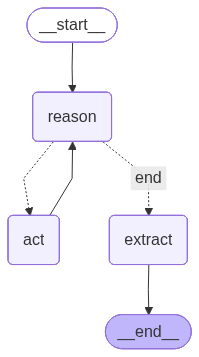
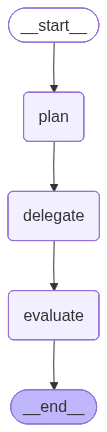
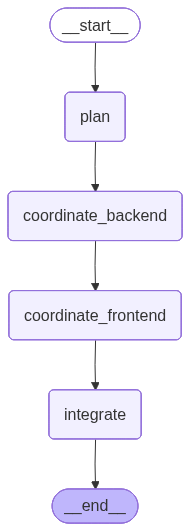

In [9]:
# 1. Capture the raw image data from your agents
raw_img1 = backend_developer_agent.get_graph().draw_mermaid_png(draw_method=MermaidDrawMethod.API)
raw_img2 = backend_team_lead_agent.get_graph().draw_mermaid_png(draw_method=MermaidDrawMethod.API)
raw_img3 = multitier_system.get_graph().draw_mermaid_png(draw_method=MermaidDrawMethod.API)

# 2. Helper to generate HTML with a title and fixed image height
def get_html_cell(binary_data, title):
    b64 = base64.b64encode(binary_data).decode()
    return f'''
    <div style="flex: 1; padding: 10px; text-align: center; border: 1px solid #eee; margin: 5px; border-radius: 8px;">
        <h4 style="margin-top: 0; color: #333; font-family: sans-serif;">{title}</h4>
        <img src="data:image/png;base64,{b64}" 
             style="height: 350px; width: 100%; object-fit: contain;" />
    </div>
    '''

# 3. Combine into a flexbox row
html_output = f'''
<div style="display: flex; flex-direction: row; justify-content: space-around; align-items: stretch;">
    {get_html_cell(raw_img1, "Worker Agent (ReAct)")}
    {get_html_cell(raw_img2, "Team Lead")}
    {get_html_cell(raw_img3, "Project Manager")}
</div>
'''

display(HTML(html_output))

## Example: Run the multi-tier autonomous agent system
Let's see the agentic multi-tier hierarchical pattern in action. Observe how each agent makes its own decisions rather than following a script.

In [10]:
# Example: Build a user authentication system
user_request = "Build a user authentication system with login, registration, and password reset functionality."

initial_state = ProjectManagerState(
    messages=[HumanMessage(content=user_request)],
    user_request=user_request,
    project_plan="",
    backend_deliverable="",
    frontend_deliverable="",
    final_deliverable=""
)

print("=== Hierarchical Multi-Tier Autonomous Agent System ===")
print(f"\nUser request: {user_request}\n")
print("Agent hierarchy:")
print("  Tier 1: Project Manager (plans, coordinates, integrates)")
print("  Tier 2: Backend Team Lead + Frontend Team Lead (supervise their own teams)")
print("  Tier 3: 4 worker agents, each running a ReAct loop with tool access")
print("\n" + "=" * 70 + "\n")

result = multitier_system.invoke(initial_state)

# Display results
print("=" * 70)
print("PROJECT MANAGER'S PLAN (Tier 1 — reasoning output)")
print("=" * 70)
print(result["project_plan"][:500] + "...\n" if len(result["project_plan"]) > 500 else result["project_plan"] + "\n")

print("=" * 70)
print("BACKEND TEAM DELIVERABLE (Tier 2 + Tier 3 — agent collaboration)")
print("=" * 70)
print(result["backend_deliverable"][:500] + "...\n" if len(result["backend_deliverable"]) > 500 else result["backend_deliverable"] + "\n")

print("=" * 70)
print("FRONTEND TEAM DELIVERABLE (Tier 2 + Tier 3 — agent collaboration)")
print("=" * 70)
print(result["frontend_deliverable"][:500] + "...\n" if len(result["frontend_deliverable"]) > 500 else result["frontend_deliverable"] + "\n")

print("=" * 70)
print("FINAL INTEGRATED DELIVERABLE (Project Manager integration)")
print("=" * 70)
print(result["final_deliverable"])
print("=" * 70)

=== Hierarchical Multi-Tier Autonomous Agent System ===

User request: Build a user authentication system with login, registration, and password reset functionality.

Agent hierarchy:
  Tier 1: Project Manager (plans, coordinates, integrates)
  Tier 2: Backend Team Lead + Frontend Team Lead (supervise their own teams)
  Tier 3: 4 worker agents, each running a ReAct loop with tool access


PROJECT MANAGER'S PLAN (Tier 1 — reasoning output)
### Project Plan for User Authentication System

#### Overview
The goal is to build a user authentication system that includes login, registration, and password reset functionalities. This system will ensure secure access to the application and manage user credentials effectively.

---

### System Requirements
1. **User Registration**: Users should be able to create an account by providing necessary information (e.g., email, password).
2. **User Login**: Users should be able to log in using thei...

BACKEND TEAM DELIVERABLE (Tier 2 + Tier 3 — agent co

In this execution, we see hierarchical multi-agent autonomy:
- Project manager reasoned about the user request and produced a project plan - it was not told what the plan should be. It then reasoned about what to give each team and passed backend context to the frontend team based on its own judgment.
- Backend team lead reasoned about the requirements and decided what tasks to assign to the backend developer and database expert. It then evaluated their outputs and produced an integrated backend deliverable.
- Frontend team lead did the same for the UI developer and UX designer. Its workers autonomously fetched the API contract during their own reasoning loops - without being told to do so by a fixed script.
- Worker agents - each ran a ReAct loop: they reasoned about their task, decided which tools to call, observed the results, and continued reasoning until they were satisfied with their output.

This pattern is ideal for complex, open-ended projects where the exact steps cannot be predetermined. When the work requires adaptive reasoning at every level of the organization - not just at the top - the hierarchical multi-tier autonomous agent pattern provides the right structure.